In [1]:
!ls /kaggle/input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection


stage_2_sample_submission.csv  stage_2_test  stage_2_train  stage_2_train.csv


NEW TRIAL : 

In [19]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import pydicom
import cv2


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [20]:
LABEL_COLUMNS = [
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
]

NUM_CLASSES = len(LABEL_COLUMNS)
print("Number of classes:", NUM_CLASSES)


Number of classes: 5


In [21]:
#labels_df = pd.read_csv("/kaggle/input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection")
RSNA_PATH = "/kaggle/input/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection"
IMAGE_DIR = RSNA_PATH + "/stage_2_train"

labels_df = pd.read_csv(f"{RSNA_PATH}/stage_2_train.csv")
labels_df.head()
#print(labels_df.head())

,ID,Label
0,ID_12cadc6af_epidural,0
1,ID_12cadc6af_intraparenchymal,0
2,ID_12cadc6af_intraventricular,0
3,ID_12cadc6af_subarachnoid,0
4,ID_12cadc6af_subdural,0


In [22]:
# Split ID into ImageID and HemorrhageType
labels_df["ImageID"] = labels_df["ID"].apply(lambda x: x.split("_")[1])
labels_df["HemorrhageType"] = labels_df["ID"].apply(lambda x: x.split("_")[2])

label_map = labels_df.pivot_table(
    index="ImageID",
    columns="HemorrhageType",
    values="Label",
    aggfunc="max"
).reset_index()

label_map = label_map.fillna(0)

label_map = label_map[["ImageID"] + LABEL_COLUMNS]

print(label_map.head())
print("Total images:", len(label_map))



HemorrhageType    ImageID  epidural  intraparenchymal  intraventricular  \
0               000012eaf         0                 0                 0   
1               000039fa0         0                 0                 0   
2               00005679d         0                 0                 0   
3               00008ce3c         0                 0                 0   
4               0000950d7         0                 0                 0   

HemorrhageType  subarachnoid  subdural  
0                          0         0  
1                          0         0  
2                          0         0  
3                          0         0  
4                          0         0  
Total images: 752803


In [24]:
!pip install albumentations


In [25]:
positive_df = label_map[label_map[LABEL_COLUMNS].sum(axis=1) > 0].sample(6000, random_state=42)
negative_df = label_map[label_map[LABEL_COLUMNS].sum(axis=1) == 0].sample(6000, random_state=42)

balanced_df = pd.concat([positive_df, negative_df]).sample(frac=1).reset_index(drop=True)

print("Balanced size:", len(balanced_df))
print(balanced_df[LABEL_COLUMNS].sum())


Balanced size: 12000
HemorrhageType
epidural             183
intraparenchymal    2046
intraventricular    1387
subarachnoid        1937
subdural            2729
dtype: int64


In [ ]:
# Create a 4000-sample balanced dataset

pos_sample = positive_df.sample(n=6000, random_state=42)
neg_sample = negative_df.sample(n=6000, random_state=42)

balanced_df = (
    pd.concat([pos_sample, neg_sample])
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print("Balanced df size:", len(balanced_df))
print(
    "Positive scans:",
    (balanced_df[LABEL_COLUMNS].sum(axis=1) > 0).sum()
)
print(
    "Negative scans:",
    (balanced_df[LABEL_COLUMNS].sum(axis=1) == 0).sum()
)


In [26]:
import os
import cv2
import pydicom
import numpy as np
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class RSNADataset(Dataset):
    def __init__(self, image_dir, dataframe, label_cols, transform=None):
        self.image_dir = image_dir
        self.df = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform = transform

    def apply_window(self, hu, center, width):
        lower = center - width // 2
        upper = center + width // 2
        hu = np.clip(hu, lower, upper)
        return (hu - lower) / (upper - lower)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row["ImageID"]
        label = row[self.label_cols].values.astype("float32")
        dcm_path = os.path.join(self.image_dir, f"ID_{image_id}.dcm")

        try:
            dicom = pydicom.dcmread(dcm_path)
            img = dicom.pixel_array.astype(np.float32)
            slope = getattr(dicom, "RescaleSlope", 1.0)
            intercept = getattr(dicom, "RescaleIntercept", 0.0)
            hu = img * slope + intercept
            hu = np.clip(hu, -1000, 1000)
        except:
            hu = np.zeros((512, 512), dtype=np.float32)
            label = np.zeros(len(self.label_cols), dtype=np.float32)

        hu = cv2.resize(hu, (512, 512), interpolation=cv2.INTER_LINEAR)
        # Apply CT windows
        brain = self.apply_window(hu, center=40, width=80)
        subdural = self.apply_window(hu, center=80, width=200)
        bone = self.apply_window(hu, center=600, width=2000)
        image = np.stack([brain, subdural, bone], axis=-1)  # HWC for albumentations

        if self.transform:
            image = self.transform(image=image)["image"]  # CHW ✅

        return image, torch.tensor(label, dtype=torch.float32)
        #if self.transform:
         #   augmented = self.transform(image=hu)
          #  hu = augmented['image']

        # Convert to CHW
        #return hu, torch.tensor(label, dtype=torch.float32)



In [27]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(
        translate_percent=0.05,
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        p=0.5
    ),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.5),
    ToTensorV2()
])

val_transform = A.Compose([
    ToTensorV2()
])


In [28]:
import torch
import torch.nn as nn
import torchvision.models as models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load ResNet34 (ImageNet pretrained)
model = models.resnet34(pretrained=True)

# Replace final layer for 5 hemorrhage classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Move model to GPU/CPU
model = model.to(device)

print("Model ready ✔")
print("Output classes:", model.fc.out_features)


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready ✔
Output classes: 5


In [29]:
import torch.nn as nn

pos_weight = torch.tensor(
    [52.33, 4.68, 7.65, 5.25, 3.54],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("✅ Weighted BCE loss restored")
print("Loss & optimizer ready ✔")


✅ Weighted BCE loss restored
Loss & optimizer ready ✔


In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df[LABEL_COLUMNS].sum(axis=1) > 0
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

print(
    "Train positives:",
    (train_df[LABEL_COLUMNS].sum(axis=1) > 0).sum()
)
print(
    "Val positives:",
    (val_df[LABEL_COLUMNS].sum(axis=1) > 0).sum()
)


Train size: 9600
Val size: 2400
Train positives: 4800
Val positives: 1200


In [30]:
from sklearn.model_selection import train_test_split

# Step 1: split out TEST set (15%)
train_val_df, test_df = train_test_split(
    label_map,
    test_size=0.15,
    random_state=42,
    stratify=label_map[LABEL_COLUMNS].sum(axis=1) > 0
)

# Step 2: split TRAIN / VAL (from remaining 85%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,  # ≈ 15% of total
    random_state=42,
    stratify=train_val_df[LABEL_COLUMNS].sum(axis=1) > 0
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))


Train size: 527262
Val size: 112620
Test size: 112921


In [31]:
train_df_small = train_df.sample(120000, random_state=42)

print("Train (full):", len(train_df))
print("Train (small):", len(train_df_small))
print("Epidural positives:", train_df_small["epidural"].sum())


Train (full): 527262
Train (small): 120000
Epidural positives: 530


In [32]:
from torch.utils.data import WeightedRandomSampler
import numpy as np

# 1️⃣ Keep your dataset the same
train_dataset = RSNADataset(
    image_dir=IMAGE_DIR,
    dataframe=train_df_small,
    label_cols=LABEL_COLUMNS,
    transform=train_transform
)

val_dataset = RSNADataset(
    image_dir=IMAGE_DIR,
    dataframe=val_df,
    label_cols=LABEL_COLUMNS,
    transform=val_transform
)

# 2️⃣ Compute sample weights for oversampling epidural
sample_weights = np.ones(len(train_dataset), dtype=np.float32)
for i, row in enumerate(train_df_small.itertuples()):
    if row.epidural == 1:
        sample_weights[i] = 5.0  # oversample factor

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 3️⃣ Create train_loader with sampler (replace shuffle=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    sampler=sampler,  # use sampler instead of shuffle
    num_workers=2,
    pin_memory=True
)

# Validation loader stays the same
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 7500
Val batches: 7039


In [18]:
"""print("About to fetch one batch")

images, labels = next(iter(train_loader))

print("Fetched batch!")
print(images.shape, labels.shape)
"""

About to fetch one batch
Fetched batch!
torch.Size([16, 3, 512, 512]) torch.Size([16, 5])


In [28]:
import torch

# Count positives per class in training set
pos_counts = train_df[LABEL_COLUMNS].sum().values
neg_counts = len(train_df) - pos_counts

# Compute pos_weight for BCEWithLogitsLoss
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32).to(device)
print("Class pos_weight:", pos_weight)


Class pos_weight: tensor([53.2373,  4.7041,  7.6957,  5.2378,  3.5911], device='cuda:0')


In [33]:
num_epochs = 3  # or more if you want
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.float32)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 🔴 ADD THIS PART
        if batch_idx % 1000 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}] | "
                f"Batch [{batch_idx}/{len(train_loader)}] | "
                f"Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}] completed | Avg Train Loss: {epoch_loss:.4f}")


    # ---------- Validation ----------
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.float32)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

    val_loss /= len(val_dataset)

    # ---------- Checkpoint ----------
    ckpt_path = f"/kaggle/working/ich_epoch_{epoch+1}.pth"
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "val_loss": val_loss
    }, ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_model_weighted.pth")
        print("✅ New best weighted-BCE model saved")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Checkpoint saved at {ckpt_path}")


Epoch [1/3] | Batch [0/7500] | Loss: 0.8631
Epoch [1/3] | Batch [1000/7500] | Loss: 0.6736
Epoch [1/3] | Batch [2000/7500] | Loss: 0.4071
Epoch [1/3] | Batch [3000/7500] | Loss: 0.2075
Epoch [1/3] | Batch [4000/7500] | Loss: 0.6101


KeyboardInterrupt: 

In [18]:
import time

start = time.time()

for i, (images, labels) in enumerate(train_loader):
    print("Loaded batch", i)
    print("Batch load time:", time.time() - start)
    break


Loaded batch 0
Batch load time: 0.7128207683563232


In [16]:
best_model_path = "/kaggle/working/best_model_weighted.pth"

model.load_state_dict(torch.load(best_model_path))
model.eval()

print("✅ Loaded best ResNet-34 weighted-BCE model")


✅ Loaded best ResNet-34 weighted-BCE model


In [28]:
import os

print("Files in /kaggle/working:")
for f in os.listdir("/kaggle/working"):
    print(f)


Files in /kaggle/working:
ich_epoch_1.pth
ich_epoch_3.pth
best_model_focal.pth
ich_epoch_2.pth
.virtual_documents


In [18]:
import torch
from sklearn.metrics import f1_score
import numpy as np

# --- 1️⃣ Load best ResNet-34 weighted-BCE model ---
model.load_state_dict(torch.load("/kaggle/working/best_model_weighted.pth"))
model.eval()
print("✅ Loaded best ResNet-34 model")

# --- 2️⃣ Collect all labels & predictions ---
all_labels = []
all_outputs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.float32)

        outputs = torch.sigmoid(model(images))  # multi-label probabilities
        all_labels.append(labels.cpu())
        all_outputs.append(outputs.cpu())

all_labels = torch.cat(all_labels).numpy()
all_outputs = torch.cat(all_outputs).numpy()

# --- 3️⃣ Tune thresholds per class ---
best_thresholds = []
print("🔧 Tuning thresholds per class:")

for i, col in enumerate(LABEL_COLUMNS):
    best_f1 = 0.0
    best_t = 0.5
    for t in np.arange(0.05, 1.0, 0.05):
        preds = (all_outputs[:, i] > t).astype(int)
        f1 = f1_score(all_labels[:, i], preds)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds.append(best_t)
    print(f"{col}: Best Threshold = {best_t:.2f}, F1 = {best_f1:.4f}")

best_thresholds = np.array(best_thresholds)

# --- 4️⃣ Compute final macro F1 using tuned thresholds ---
final_preds = (all_outputs > best_thresholds).astype(int)
macro_f1 = f1_score(all_labels, final_preds, average="macro")

print(f"\n🔥 Final Macro F1 (tuned thresholds) = {macro_f1:.4f}")


✅ Loaded best ResNet-34 model
🔧 Tuning thresholds per class:
epidural: Best Threshold = 0.90, F1 = 0.2376
intraparenchymal: Best Threshold = 0.85, F1 = 0.6995
intraventricular: Best Threshold = 0.90, F1 = 0.7388
subarachnoid: Best Threshold = 0.85, F1 = 0.5675
subdural: Best Threshold = 0.50, F1 = 0.6567

🔥 Final Macro F1 (tuned thresholds) = 0.5800


In [19]:
import torch

# ------------------------------
# 1️⃣ Save the best ResNet-34 model
# ------------------------------
torch.save(model.state_dict(), "/kaggle/working/best_model_resnet34.pth")
print("✅ Saved best ResNet-34 model as best_model_resnet34.pth")

# ------------------------------
# 2️⃣ Load it for inference
# ------------------------------
model.load_state_dict(torch.load("/kaggle/working/best_model_resnet34.pth"))
model.eval()
print("✅ Loaded best ResNet-34 model for inference or Grad-CAM")



✅ Saved best ResNet-34 model as best_model_resnet34.pth
✅ Loaded best ResNet-34 model for inference or Grad-CAM


In [33]:
from sklearn.metrics import f1_score
import numpy as np

all_labels = []
all_outputs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.float32)

        logits = model(images)
        probs = torch.sigmoid(logits)

        all_labels.append(labels.cpu())
        all_outputs.append(probs.cpu())

all_labels = torch.cat(all_labels).numpy()
all_outputs = torch.cat(all_outputs).numpy()


In [34]:
print("Per-class F1 scores (threshold = 0.5):")

f1s = []
for i, col in enumerate(LABEL_COLUMNS):
    preds = (all_outputs[:, i] > 0.5).astype(int)
    f1 = f1_score(all_labels[:, i], preds)
    f1s.append(f1)
    print(f"{col}: F1 = {f1:.4f}")

macro_f1 = np.mean(f1s)
print(f"\nMacro F1 = {macro_f1:.4f}")


Per-class F1 scores (threshold = 0.5):
epidural: F1 = 0.0759
intraparenchymal: F1 = 0.6538
intraventricular: F1 = 0.5527
subarachnoid: F1 = 0.5989
subdural: F1 = 0.5496

Macro F1 = 0.4862


In [24]:
ckpt_path = "/kaggle/working/ich_epoch_3.pth"

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])


Loaded checkpoint from epoch: 3
Validation loss: 0.2546397933363915


In [28]:
from sklearn.metrics import f1_score
import numpy as np

y_pred_final = np.zeros_like(all_probs)

for i, col in enumerate(LABEL_COLUMNS):
    y_pred_final[:, i] = (all_probs[:, i] >= best_thresholds[col]).astype(int)

macro_f1 = f1_score(all_labels, y_pred_final, average="macro", zero_division=0)
print("Final Macro F1 (tuned):", macro_f1)


Final Macro F1 (tuned): 0.5399931071718583


In [32]:
torch.save({
    "model_state_dict": model.state_dict(),
    "best_thresholds": best_thresholds,
    "macro_f1": 0.53999,
    "macro_auc": 0.8608,
    "epochs": 3,
    "dataset_size": 4000,
    "notes": "ResNet + 3-window CT preprocessing + Albumentations + threshold tuning"
}, "/kaggle/working/ICH_ResNet_v1_MacroF1_0.54.pth")


In [58]:
import numpy as np

np.save("/kaggle/working/best_thresholds.npy", best_thresholds)
print("✅ Thresholds saved")


✅ Thresholds saved


In [20]:
from sklearn.metrics import classification_report

final_preds = (all_outputs > best_thresholds).astype(int)

print(
    classification_report(
        all_labels,
        final_preds,
        target_names=LABEL_COLUMNS,
        zero_division=0
    )
)


                  precision    recall  f1-score   support

        epidural       0.17      0.38      0.24        32
intraparenchymal       0.79      0.63      0.70       409
intraventricular       0.68      0.80      0.74       268
    subarachnoid       0.59      0.55      0.57       372
        subdural       0.56      0.80      0.66       549

       micro avg       0.61      0.69      0.65      1630
       macro avg       0.56      0.63      0.58      1630
    weighted avg       0.64      0.69      0.65      1630
     samples avg       0.32      0.34      0.32      1630



In [21]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.7 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.9


Image 1:
Hemorrhage present: No

Image 2:
Hemorrhage present: Yes
Type(s): ['subarachnoid']


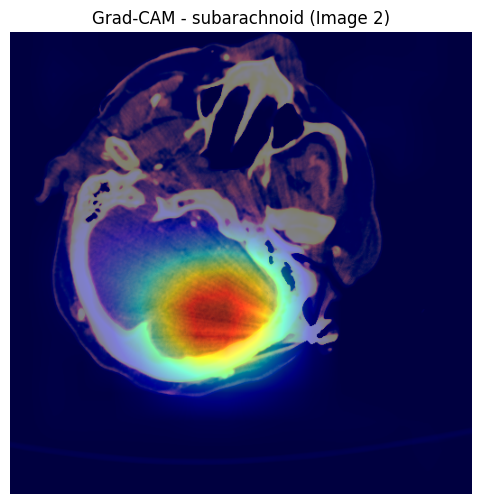


Image 3:
Hemorrhage present: No

Image 4:
Hemorrhage present: Yes
Type(s): ['intraparenchymal', 'intraventricular']


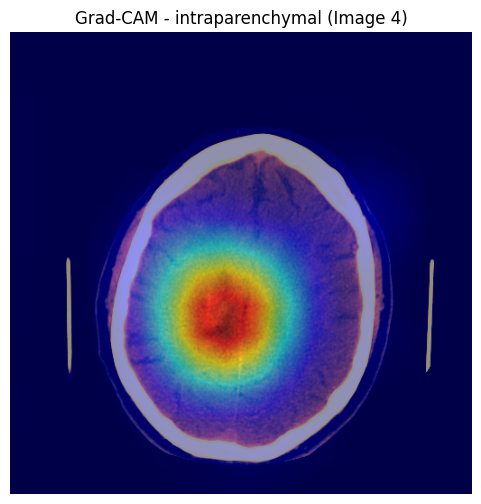

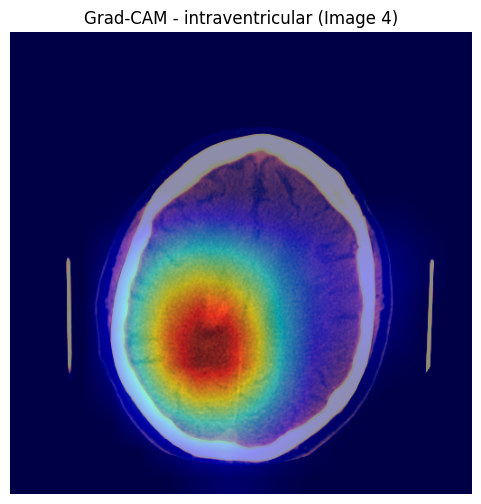

In [22]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.eval()
target_layer = model.layer4[-1]  # last conv layer

# Pick first 4 images from validation
images, labels = next(iter(val_loader))
img_tensors = images[:4].to(device, dtype=torch.float32)

for idx, img_tensor in enumerate(img_tensors):
    original_img = img_tensor.permute(1,2,0).cpu().numpy()
    original_img = (original_img - original_img.min()) / (original_img.max() - original_img.min())

    # Hemorrhage presence & types
    with torch.no_grad():
        outputs = torch.sigmoid(model(img_tensor.unsqueeze(0)))
        preds = (outputs > torch.tensor(best_thresholds).to(device))
        any_hemm = preds.any(dim=1).int()

    print(f"\nImage {idx+1}:")
    if any_hemm[0]:
        print("Hemorrhage present: Yes")
        present_types = [LABEL_COLUMNS[i] for i, p in enumerate(preds[0]) if p]
        print("Type(s):", present_types)
    else:
        print("Hemorrhage present: No")
        present_types = []

    # Grad-CAM
    cam = GradCAM(model=model, target_layers=[target_layer])
    for class_idx, present in enumerate(preds[0]):
        if present:
            targets = [ClassifierOutputTarget(class_idx)]
            grayscale_cam = cam(input_tensor=img_tensor.unsqueeze(0), targets=targets)
            visualization = show_cam_on_image(original_img, grayscale_cam[0], use_rgb=True)

            plt.figure(figsize=(6,6))
            plt.imshow(visualization)
            plt.title(f"Grad-CAM - {LABEL_COLUMNS[class_idx]} (Image {idx+1})")
            plt.axis('off')
            plt.show()
